# DL modeling

 - time
 - EU 480
 - spettrale

 - [yolov8-seg model structure](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/models/v8/yolov8-seg.yaml)
 - [LULC prediction for Slovenia](https://github.com/sentinel-hub/eo-learn/blob/master/examples/land-cover-map/SI_LULC_pipeline.ipynb)
 - [Land Cover Classification with eo-learn: Part 1](https://medium.com/sentinel-hub/land-cover-classification-with-eo-learn-part-1-2471e8098195)
 - [Claudio Russo GitHub](https://github.com/claudio9russo7/yolo) for yolo docker managementfor yolo docker management
 - [...more then 3 bands in YOLO](https://github.com/ultralytics/yolov5/issues/7825)

## Load

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# %load import.py
#
from IPython.display import IFrame

# 
import numpy as np
import pandas as pd

#
from sentinelsat import SentinelAPI, read_geojson, geojson_to_wkt
from datetime import date

#
import rioxarray
import geopandas as gpd
import rasterio as rio

#
from matplotlib import pyplot
from rasterio.plot import show

#
from sqlalchemy import create_engine # query PostGIS
from sqlalchemy import inspect

#
import osmnx as ox

#
from shapely.geometry import Polygon, box, MultiPolygon
import shapely.ops as so

#
import json

#
import os
from pathlib import Path
import fnmatch
import glob

#
from osgeo import gdal

#
import random

#
import shutil

#
from tqdm import tqdm
import time

#
import folium
from folium import plugins

### Model Structure

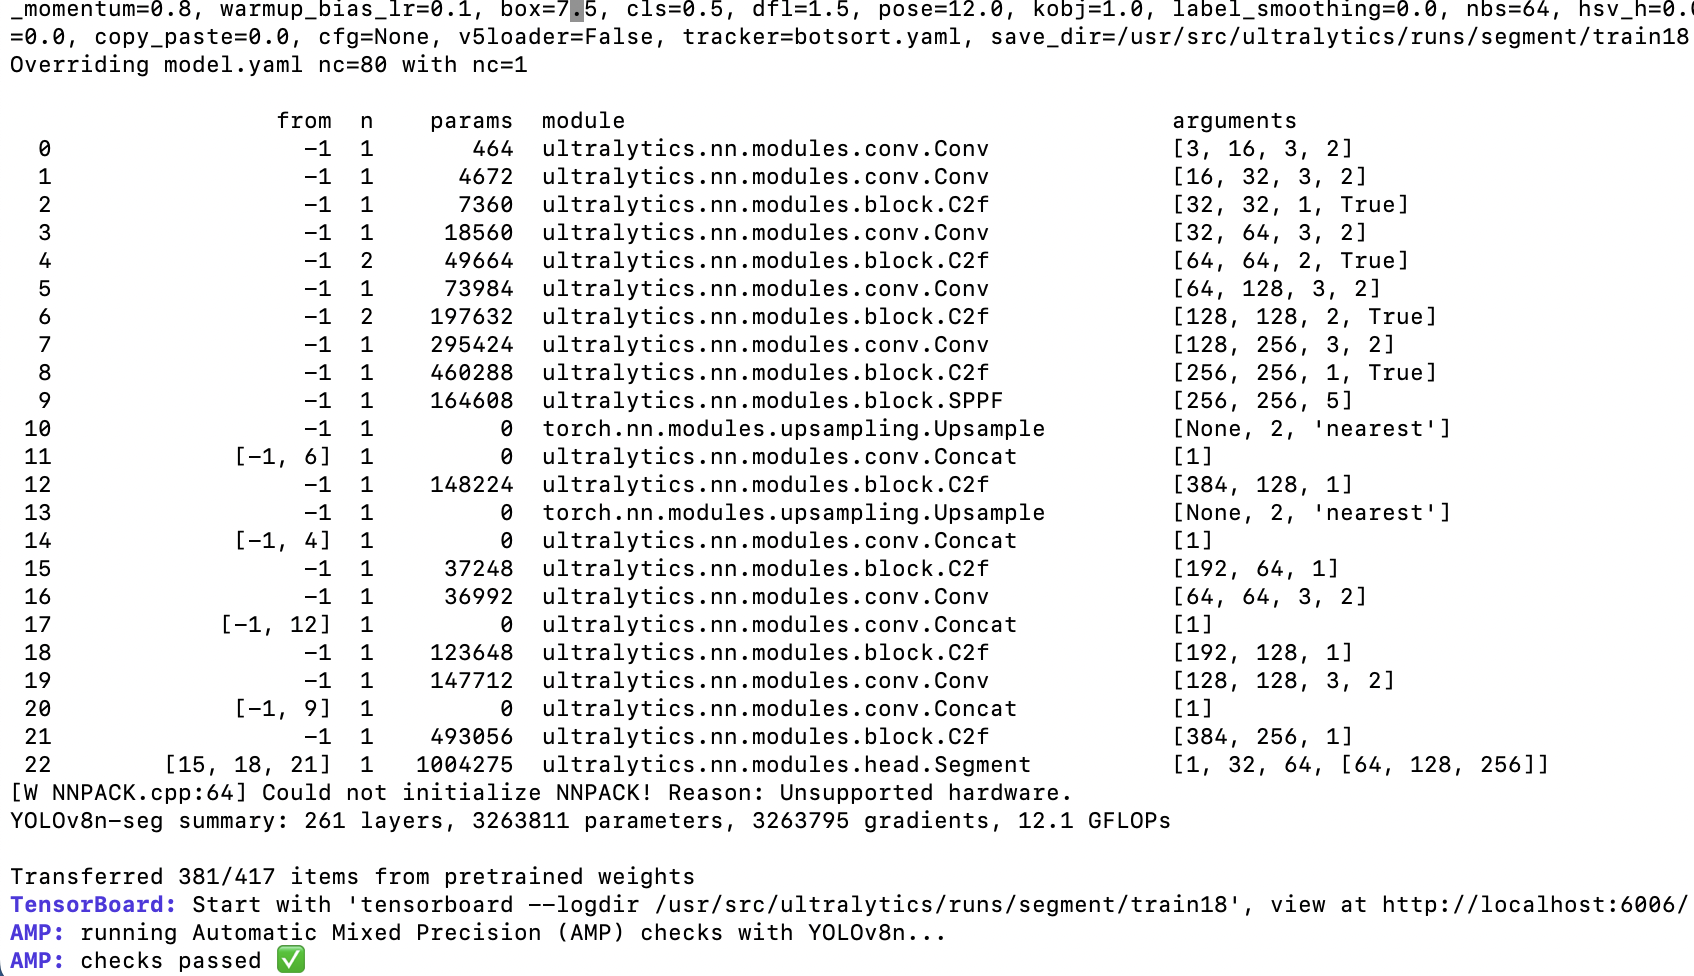

### Organization of directories

 - datasets
   - imp_class
     - images
       - train
         - e.g. `S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004__001_003.tif`
       - val
         - ...
     - labels
       - train
         - e.g. `S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004__001_003.txt`
       - val
         - ...
 
 - yamls
   - imp_class.yaml

**This is the content of the imp_class.yaml file:**

```BASH

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: ../datasets/imp_class  # dataset root dir
train: images/train          # train images (relative to 'path')
val: images/val              # val images (relative to 'path')


# Classes
names:
  0: building
  1: street
```

#### organize directories for yolo run

In [ ]:
tileSize = 32*15
print("Tile size %d x %d." % (tileSize,tileSize))

In [ ]:
project = 'imp_class_' + str(tileSize) + 'x' + str(tileSize)
train = 'train'
validation = 'val'
testing = 'test'
perc_tr = 0.7 # percentage of instances given to training
perc_va = 0.2 # percentage of instances given to validation
# residual of [1 - (perc_tr + perc_va)] is given to testing subset!
print('Project: ',project)

In [ ]:
dir_annotation = "annotations/" + str(tileSize) + "x" + str(tileSize) + "/" + project
dir_annotation

In [ ]:
sel_prod_gdf = gpd.read_file("sel_products.geojson")

In [ ]:
prod_id = sel_prod_gdf["title"][0]
prod_id

In [ ]:
dir_annotation_ras = "annotations/" + str(tileSize) + "x" + str(tileSize) + "/" + prod_id + "/"
dir_annotation_ras

In [ ]:
if not os.path.exists(dir_annotation):
    os.mkdir( dir_annotation )

p = dir_annotation + '/images/' + train
if not os.path.exists(p):
    os.makedirs( p )
p = dir_annotation + '/images/' + validation
if not os.path.exists(p):
    os.makedirs( p )
p = dir_annotation + '/images/' + testing
if not os.path.exists(p):
    os.makedirs( p )
    
p = dir_annotation + '/labels/' + train
if not os.path.exists(p):
    os.makedirs( p )
p = dir_annotation + '/labels/' + validation
if not os.path.exists(p):
    os.makedirs( p )
p = dir_annotation + '/labels/' + testing
if not os.path.exists(p):
    os.makedirs( p )

In [ ]:
N = len(glob.glob( dir_annotation_ras + '*.txt' ))
print("%d annotation text files found in %s" % (N,dir_annotation_ras))

In [ ]:
random.seed(3008)
rs = random.sample(range(N), N)

i=-1
for f in glob.glob( dir_annotation_ras + '*.txt' ):
    i=i+1

    # load TIF bbox:
    ftif = f.split('.txt')[0] + '.tif'

    print("\n%04d\t%s" % (i,f.split("/")[3]))
    print("\n%04s\t%s" % ('',ftif.split("/")[3]))
    
    # copy file in training folder:
    if (i+1) in rs[0:round(N * perc_tr)]:
        shutil.copy(ftif, dir_annotation + '/images/' + train + '/' + ftif.split("/")[3] )
        shutil.copy(f,    dir_annotation + '/labels/' + train + '/' +    f.split("/")[3] )
        print("\n%04s\t%s" % ('',train))

    elif (i+1) in rs[0:round(N * (perc_tr+perc_va))]:
        shutil.copy(ftif, dir_annotation + '/images/' + validation + '/' + ftif.split("/")[3] )
        shutil.copy(f,    dir_annotation + '/labels/' + validation + '/' +    f.split("/")[3] )
        print("\n%04s\t%s" % ('',validation))
    else:
        shutil.copy(ftif, dir_annotation + '/images/' + testing + '/' + ftif.split("/")[3] )
        shutil.copy(f,    dir_annotation + '/labels/' + testing + '/' +    f.split("/")[3] )
        print("\n%04s\t%s" % ('',testing))
        
    print("")

### Parameters of YOLO

 - [Usage](https://docs.ultralytics.com/usage/cfg/)
 - [DEFAULT values and their meaning](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/yolo/cfg/default.yaml)
 - [Basic Tutorial in Jupyter](https://github.com/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb)
 - [...any number of channels...](https://github.com/ultralytics/yolov5/issues/7825)

### Run the model

##### Notes

 - imgsz
   - 640 - returns OOM (having tiles at 610) - (YOLOv8n-seg summary: 261 layers, 3263811 parameters, 3263795 gradients, 12.1 GFLOPs)
   - 480 - paasing from 640 to 480 determines a reduction of GPU memory usage of one magnitude order (from 15-30 GB to 1.5-3.0 GB)

##### yolo docker

```BASH
# run docker container
docker run --ipc=host -it --name yolo --gpus all -v /media/agritech/docker-persistencies/logic-tier/yolo-train/yamls:/usr/src/ultralytics/ultralytics/datasets -v /media/agritech/docker-persistencies/logic-tier/yolo-train/datasets:/usr/src/datasets -v /media/agritech/docker-persistencies/logic-tier/yolo-train/outputs:/usr/src/ultralytics/runs ultralytics/ultralytics:latest
```

##### run#01 :: error

```BASH
yolo segment train data=imp_class.yaml model=yolov8n-seg.pt workers=1 epochs=100 imgsz=480
```

##### Issues

#### OOM (out of memory)

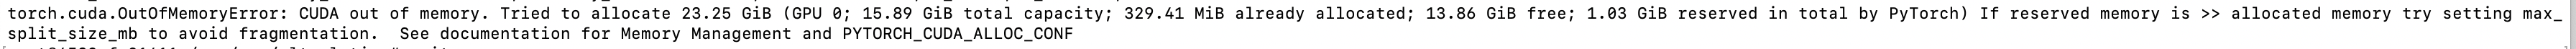

 - [yolov8 GitHub issues](https://github.com/ultralytics/ultralytics/issues/784)

##### run#02 :: good!

```BASH
yolo segment train data=imp_class.yaml model=yolov8n-seg.pt workers=1 epochs=3 imgsz=480 batch=2 cache=True save=True save_period=1
```

##### run#03 :: refinement

```BASH
yolo segment train data=imp_class_480.yaml model=yolov8n-seg.pt workers=1 epochs=100 imgsz=480 batch=2 cache=True save=True save_period=1
```